In [1]:
import pandas as pd
import numpy as np
!pip install yfinance
import yfinance as yf
!pip install yahoofinance
from yahoofinance import HistoricalPrices
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.stattools import adfuller
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

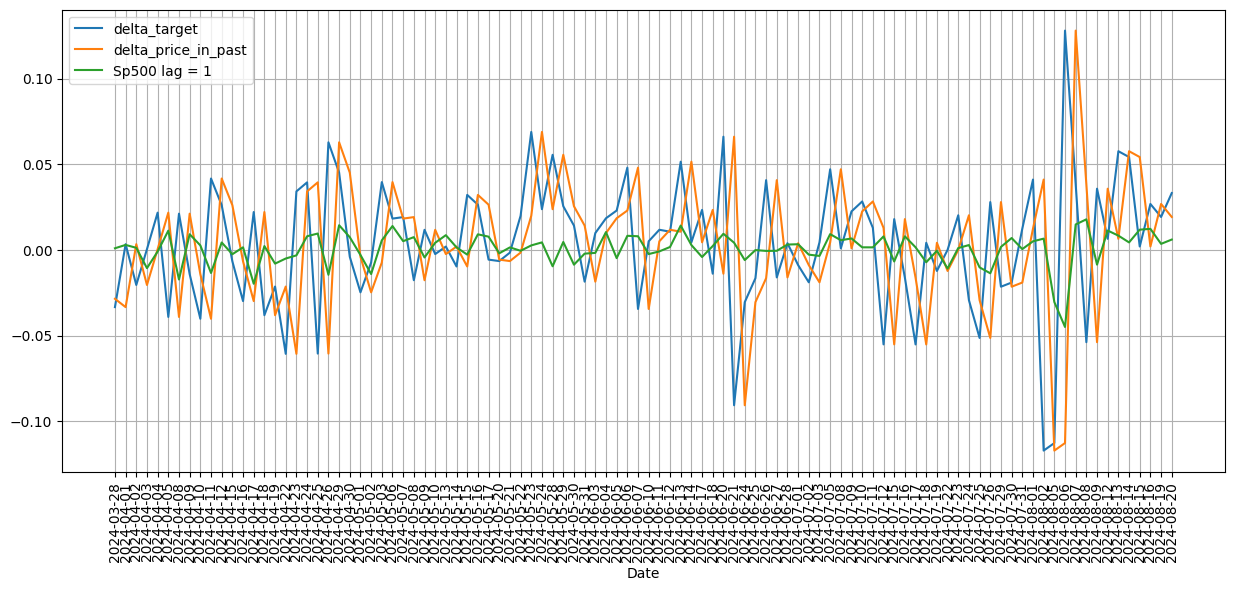

In [2]:
data_for_ml = pd.read_csv('trading.csv', sep = ',')

data_for_ml1 = data_for_ml[0:100]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(data_for_ml1['Date'], data_for_ml1['delta_target'], label='delta_target')
ax.plot(data_for_ml1['Date'], data_for_ml1['delta_price_in_past'], label='delta_price_in_past')
ax.plot(data_for_ml1['Date'], data_for_ml1['delta_sp500_in_past'], label='Sp500 lag = 1')
ax.set_xlabel('Date')
ax.set_xticks(data_for_ml1['Date'])
plt.xticks(rotation=90)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

#Data

In [3]:
#for random forest
min_app = 0
data_for_ml.loc[data_for_ml['delta_target'] > min_app, 'class'] = 'yes'
data_for_ml.loc[data_for_ml['delta_target'] <= min_app, 'class'] = 'no'

data_for_ml_train = data_for_ml[:int(len(data_for_ml)*0.8):].copy(deep = True)
data_for_ml_test = data_for_ml[int(len(data_for_ml)*0.8)::].copy(deep = True)

In [4]:
data_for_ml_train

,Unnamed: 0,Date,target,Volume,Volume_in_past1,Volume_in_past2,price_in_past1,price_in_past2,delta_target,delta_price_in_past,delta_volume_in_past,sp500,sp500_in_past1,sp500_in_past2,delta_sp500_in_past,class
0,0,2024-03-28,89.970431,435212000,586067000.0,513648000.0,93.081411,95.819506,-0.033422,-0.028576,0.140990,516.634532,515.153358,514.679364,0.000921,no
1,1,2024-04-01,90.269339,452441000,435212000.0,586067000.0,89.970431,93.081411,0.003322,-0.033422,-0.257402,517.246773,516.634532,515.153358,0.002875,yes
2,2,2024-04-02,88.418939,433064000,452441000.0,435212000.0,90.269339,89.970431,-0.020499,0.003322,0.039588,511.726962,517.246773,516.634532,0.001185,no
3,3,2024-04-03,88.454938,370067000,433064000.0,452441000.0,88.418939,90.269339,0.000407,-0.020499,-0.042828,511.213500,511.726962,517.246773,-0.010672,yes
4,4,2024-04-04,90.376298,434965000,370067000.0,433064000.0,88.454938,88.418939,0.021721,0.000407,-0.145468,516.940660,511.213500,511.726962,-0.001003,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,194,2025-01-06,148.576325,265377400,229322500.0,198247200.0,139.997114,135.987487,0.061281,0.029485,0.156750,594.481707,585.767895,587.622351,-0.003156,yes
195,195,2025-01-07,153.015919,351782200,265377400.0,229322500.0,148.576325,139.997114,0.029881,0.061281,0.157224,595.628240,594.481707,585.767895,0.014876,yes
196,196,2025-01-08,142.566896,227349900,351782200.0,265377400.0,153.015919,148.576325,-0.068287,0.029881,0.325592,586.934376,595.628240,594.481707,0.001929,no
197,197,2025-01-10,137.437358,207602500,227349900.0,351782200.0,142.566896,153.015919,-0.035980,-0.068287,-0.353720,584.122811,586.934376,595.628240,-0.014596,no


In [5]:
data_for_ml_test

,Unnamed: 0,Date,target,Volume,Volume_in_past1,Volume_in_past2,price_in_past1,price_in_past2,delta_target,delta_price_in_past,delta_volume_in_past,sp500,sp500_in_past1,sp500_in_past2,delta_sp500_in_past,class
199,199,2025-01-14,136.037493,195590500,204808900.0,207602500.0,129.978051,137.437358,0.046619,-0.054274,-0.013456,582.607383,574.043162,584.122811,-0.017256,yes
200,200,2025-01-15,133.637705,185217300,195590500.0,204808900.0,136.037493,129.978051,-0.017641,0.046619,-0.045010,588.559533,582.607383,574.043162,0.014919,no
201,201,2025-01-16,138.627250,209235600,185217300.0,195590500.0,133.637705,136.037493,0.037336,-0.017641,-0.053035,592.387981,588.559533,582.607383,0.010216,yes
202,202,2025-01-17,136.677431,201188800,209235600.0,185217300.0,138.627250,133.637705,-0.014065,0.037336,0.129676,595.169645,592.387981,588.559533,0.006505,no
203,203,2025-01-21,139.147203,197749000,201188800.0,209235600.0,136.677431,138.627250,0.018070,-0.014065,-0.038458,598.868466,595.169645,592.387981,0.004696,yes
204,204,2025-01-22,144.646706,237651400,197749000.0,201188800.0,139.147203,136.677431,0.039523,0.018070,-0.017097,604.102695,598.868466,595.169645,0.006215,yes
205,205,2025-01-23,145.036668,155915500,237651400.0,197749000.0,144.646706,139.147203,0.002696,0.039523,0.201783,603.983099,604.102695,598.868466,0.008740,yes
206,206,2025-01-24,148.356343,234657600,155915500.0,237651400.0,145.036668,144.646706,0.022889,0.002696,-0.343932,607.981054,603.983099,604.102695,-0.000198,yes
207,207,2025-01-27,124.788521,818830900,234657600.0,155915500.0,148.356343,145.036668,-0.158860,0.022889,0.505031,593.026066,607.981054,603.983099,0.006619,no
208,208,2025-01-28,121.798801,579666400,818830900.0,234657600.0,124.788521,148.356343,-0.023958,-0.158860,2.489471,598.818643,593.026066,607.981054,-0.024598,no


#Econometrics

AR

In [6]:
res = AutoReg(data_for_ml_train['target'], lags = 1, trend = 'c').fit()
#the first candidate for comparison
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                 target   No. Observations:                  199
Model:                     AutoReg(1)   Log Likelihood                -550.061
Method:               Conditional MLE   S.D. of innovations              3.893
Date:                Tue, 20 Jan 2026   AIC                           1106.122
Time:                        11:10:02   BIC                           1115.987
Sample:                             1   HQIC                          1110.115
                                  199                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2940      1.731      1.903      0.057      -0.099       6.687
target.L1      0.9742      0.014     68.309      0.000       0.946       1.002
                                    Roots           

In [7]:
res1 = AutoReg(data_for_ml_train['target'], lags = 1, trend = 'n').fit()
#the second candidate for comparison
print(res1.summary())

                            AutoReg Model Results                             
Dep. Variable:                 target   No. Observations:                  199
Model:                     AutoReg(1)   Log Likelihood                -551.855
Method:               Conditional MLE   S.D. of innovations              3.928
Date:                Tue, 20 Jan 2026   AIC                           1107.711
Time:                        11:10:02   BIC                           1114.287
Sample:                             1   HQIC                          1110.373
                                  199                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
target.L1      1.0010      0.002    435.190      0.000       0.996       1.005
                                    Roots                                    
                  Real          Imaginary           M

OLS

In [8]:
y = data_for_ml_train['target']
x = data_for_ml_train[['Volume_in_past1','price_in_past1']]
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                 target   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          9.422e+04
Date:                Tue, 20 Jan 2026   Prob (F-statistic):                   2.28e-294
Time:                        11:10:02   Log-Likelihood:                         -554.42
No. Observations:                 199   AIC:                                      1113.
Df Residuals:                     197   BIC:                                      1119.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [9]:
#at the 10% significance level, everything is fine
#the third candidate for comparison


y = data_for_ml_train['target']
x = data_for_ml_train[['price_in_past1', 'sp500_in_past1', 'delta_volume_in_past']]
model_final = sm.OLS(y, x)
res2 = model_final.fit()
print(res2.summary())

                                 OLS Regression Results                                
Dep. Variable:                 target   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          6.447e+04
Date:                Tue, 20 Jan 2026   Prob (F-statistic):                   3.76e-293
Time:                        11:10:02   Log-Likelihood:                         -551.33
No. Observations:                 199   AIC:                                      1109.
Df Residuals:                     196   BIC:                                      1119.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

#Machine learning

In [10]:
data_for_rf_train = data_for_ml_train[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past', 'class']].copy(deep = True)
data_for_rf_test = data_for_ml_test[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past', 'class']].copy(deep = True)
x_train = data_for_rf_train[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past']]
x_test = data_for_rf_test[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past']]
y_train_rf = data_for_rf_train['class']
y_test_rf = data_for_rf_test['class']

y_train_rf_regr = data_for_ml_train['target']
y_test_rf_regr = data_for_ml_test['target']

y_train_rf_regr1 = data_for_ml_train['delta_target']
y_test_rf_regr1 = data_for_ml_test['delta_target']

y_train_svr1 = data_for_ml_train['target']
y_test_svr1 = data_for_ml_test['target']

y_train_svr2 = data_for_ml_train['delta_target']
y_test_svr2 = data_for_ml_test['delta_target']

In [11]:
#random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train_rf)
y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test_rf, y_pred)
print('random forest classifier')
print(classification_report(y_test_rf, y_pred))

#random forest regression
rf_regr = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regr.fit(x_train, y_train_rf_regr)
y_pred_rf_regr = rf_regr.predict(x_test)
print('random forest regression')
print(mean_squared_error(y_test_rf_regr, y_pred_rf_regr))

#SVM (SVR) regression
svr1 = SVR()
svr1.fit(x_train, y_train_svr1)
y_pred_svr1 = svr1.predict(x_test)
print('SVM (SVR) regression')
print(mean_squared_error(y_test_svr1, y_pred_svr1))

#radfom forest growth analysis
rf_regr1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regr1.fit(x_train, y_train_rf_regr1)
y_pred_rf_regr1 = rf_regr1.predict(x_test)
print('radfom forest growth analysis')
print(mean_squared_error(y_test_rf_regr1, y_pred_rf_regr1))

#SVM (SVR) growth analysis
svr2 = SVR()
svr2.fit(x_train, y_train_svr2)
y_pred_svr2 = svr2.predict(x_test)
print('SVM (SVR) growth analysis')
print(mean_squared_error(y_test_svr2, y_pred_svr2))

random forest classifier
              precision    recall  f1-score   support

          no       0.44      0.70      0.54        20
         yes       0.67      0.40      0.50        30

    accuracy                           0.52        50
   macro avg       0.55      0.55      0.52        50
weighted avg       0.57      0.52      0.52        50

random forest regression
32.95164625076696
SVM (SVR) regression
59.027688240054985
radfom forest growth analysis
0.0016183064223340875
SVM (SVR) growth analysis
0.002817710172471919


In [12]:
data_for_ml_test

,Unnamed: 0,Date,target,Volume,Volume_in_past1,Volume_in_past2,price_in_past1,price_in_past2,delta_target,delta_price_in_past,delta_volume_in_past,sp500,sp500_in_past1,sp500_in_past2,delta_sp500_in_past,class
199,199,2025-01-14,136.037493,195590500,204808900.0,207602500.0,129.978051,137.437358,0.046619,-0.054274,-0.013456,582.607383,574.043162,584.122811,-0.017256,yes
200,200,2025-01-15,133.637705,185217300,195590500.0,204808900.0,136.037493,129.978051,-0.017641,0.046619,-0.045010,588.559533,582.607383,574.043162,0.014919,no
201,201,2025-01-16,138.627250,209235600,185217300.0,195590500.0,133.637705,136.037493,0.037336,-0.017641,-0.053035,592.387981,588.559533,582.607383,0.010216,yes
202,202,2025-01-17,136.677431,201188800,209235600.0,185217300.0,138.627250,133.637705,-0.014065,0.037336,0.129676,595.169645,592.387981,588.559533,0.006505,no
203,203,2025-01-21,139.147203,197749000,201188800.0,209235600.0,136.677431,138.627250,0.018070,-0.014065,-0.038458,598.868466,595.169645,592.387981,0.004696,yes
204,204,2025-01-22,144.646706,237651400,197749000.0,201188800.0,139.147203,136.677431,0.039523,0.018070,-0.017097,604.102695,598.868466,595.169645,0.006215,yes
205,205,2025-01-23,145.036668,155915500,237651400.0,197749000.0,144.646706,139.147203,0.002696,0.039523,0.201783,603.983099,604.102695,598.868466,0.008740,yes
206,206,2025-01-24,148.356343,234657600,155915500.0,237651400.0,145.036668,144.646706,0.022889,0.002696,-0.343932,607.981054,603.983099,604.102695,-0.000198,yes
207,207,2025-01-27,124.788521,818830900,234657600.0,155915500.0,148.356343,145.036668,-0.158860,0.022889,0.505031,593.026066,607.981054,603.983099,0.006619,no
208,208,2025-01-28,121.798801,579666400,818830900.0,234657600.0,124.788521,148.356343,-0.023958,-0.158860,2.489471,598.818643,593.026066,607.981054,-0.024598,no


#Comparison of methods

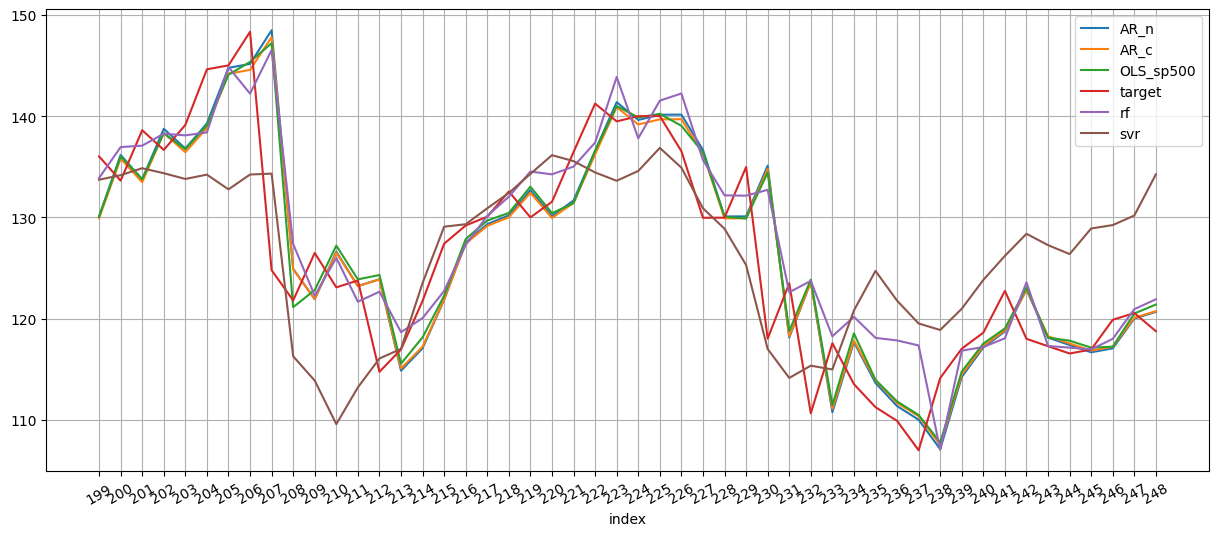

In [13]:
#AR without trend
coef_ar_n = 1.0010
AR_n = pd.DataFrame()
AR_c = pd.DataFrame()

AR_n['price_in_past1'] = data_for_ml_test['price_in_past1'].copy(deep = True)
AR_n['pred'] = AR_n['price_in_past1'] * coef_ar_n
#AR with trend
coef_ar_c = 0.9742
const_ar_c = 3.2940

AR_c['price_in_past1'] = data_for_ml_test['price_in_past1'].copy(deep = True)
AR_c['pred'] = AR_c['price_in_past1'] * coef_ar_c + const_ar_c
#OLS c SP500 and last price, essentially an autoregression with exogenous variables
OLS_sp500 = res2.predict(data_for_ml_test[['price_in_past1', 'sp500_in_past1', 'delta_volume_in_past']])
mas_of_x = np.arange(199, 249)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(mas_of_x, AR_n['pred'], label='AR_n')
ax.plot(mas_of_x, AR_c['pred'], label='AR_c')
ax.plot(mas_of_x, OLS_sp500, label='OLS_sp500')
ax.plot(mas_of_x, data_for_ml_test['target'], label='target')
ax.plot(mas_of_x, y_pred_rf_regr, label='rf')
ax.plot(mas_of_x, y_pred_svr1, label='svr')

ax.set_xlabel('index')
ax.set_xticks(mas_of_x)
plt.xticks(rotation = 30)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

In [14]:
# Error: sum((target - predict)^2)
err = pd.DataFrame()
err['rf'] = (y_pred_rf_regr - data_for_ml_test['target']) ** 2
err['svr'] = (y_pred_svr1 - data_for_ml_test['target']) ** 2
err['ar_n'] = (AR_n['pred'] - data_for_ml_test['target']) ** 2
err['ar_c'] = (AR_c['pred'] - data_for_ml_test['target']) ** 2
err['ols'] = (OLS_sp500 - data_for_ml_test['target']) ** 2
err.sum()

,0
rf,1647.582313
svr,2951.384412
ar_n,1692.599888
ar_c,1649.315161
ols,1577.139986


In [15]:
#errors in ml increments methods
err_prir = pd.DataFrame()
err_prir['rf'] = (y_pred_rf_regr1 - data_for_ml_test['delta_target']) ** 2
err_prir['svr'] = (y_pred_svr2 - data_for_ml_test['delta_target']) ** 2
err_prir.sum()

,0
rf,0.080915
svr,0.140886


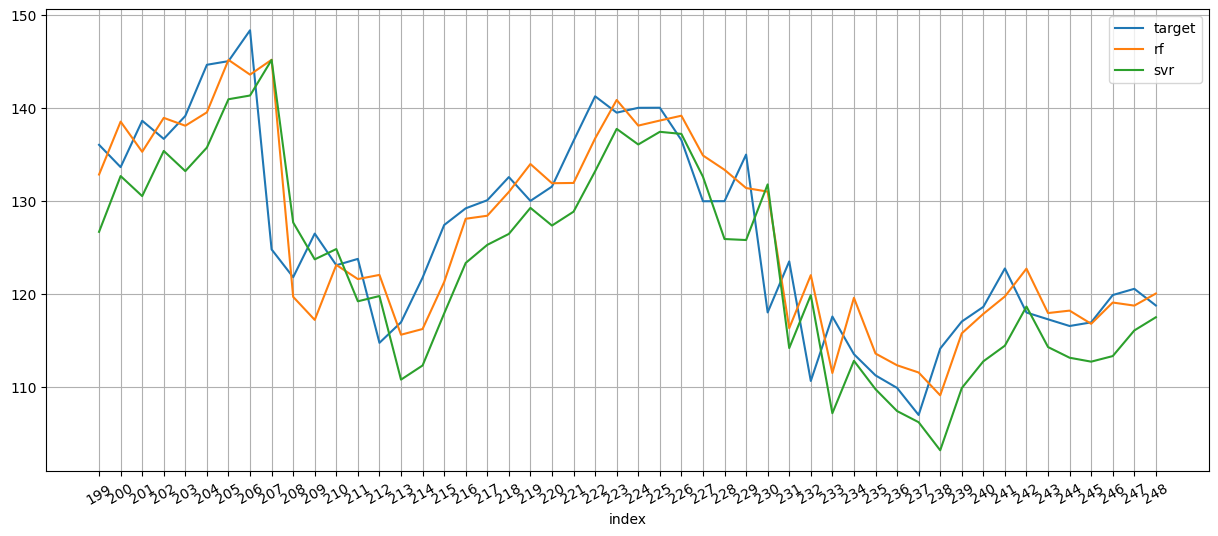

In [16]:
#graphs derived from increments
fig, ax = plt.subplots(figsize=(15, 6))

prediction_rf = (y_pred_rf_regr1 + 1) * data_for_ml_test['price_in_past1']
prediction_svr = (y_pred_svr2 + 1) * data_for_ml_test['price_in_past1']

ax.plot(mas_of_x, data_for_ml_test['target'], label='target')
ax.plot(mas_of_x, prediction_rf, label='rf')
ax.plot(mas_of_x, prediction_svr, label='svr')

ax.set_xlabel('index')
ax.set_xticks(mas_of_x)
plt.xticks(rotation = 30)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

Growth analysis

In [17]:
y = data_for_ml_train['delta_target']
x = data_for_ml_train[['delta_price_in_past', 'delta_volume_in_past', 'delta_sp500_in_past']]
model_delta = sm.OLS(y, x)
results = model_delta.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:           delta_target   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):              0.010
Method:                 Least Squares   F-statistic:                              1.651
Date:                Tue, 20 Jan 2026   Prob (F-statistic):                       0.179
Time:                        11:10:06   Log-Likelihood:                          395.45
No. Observations:                 199   AIC:                                     -784.9
Df Residuals:                     196   BIC:                                     -775.0
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [18]:
res_prir = AutoReg(data_for_ml_train['delta_target'], lags = 1, trend = 'c').fit()
print(res_prir.summary())

                            AutoReg Model Results                             
Dep. Variable:           delta_target   No. Observations:                  199
Model:                     AutoReg(1)   Log Likelihood                 391.508
Method:               Conditional MLE   S.D. of innovations              0.033
Date:                Tue, 20 Jan 2026   AIC                           -777.017
Time:                        11:10:06   BIC                           -767.152
Sample:                             1   HQIC                          -773.024
                                  199                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0024      0.002      1.013      0.311      -0.002       0.007
delta_target.L1     0.0023      0.071      0.032      0.975      -0.138       0.142
                                

In [19]:
res_prir1 = AutoReg(data_for_ml_train['delta_target'], lags = 1, trend = 'n').fit()
print(res_prir1.summary())

                            AutoReg Model Results                             
Dep. Variable:           delta_target   No. Observations:                  199
Model:                     AutoReg(1)   Log Likelihood                 390.996
Method:               Conditional MLE   S.D. of innovations              0.034
Date:                Tue, 20 Jan 2026   AIC                           -777.992
Time:                        11:10:06   BIC                           -771.416
Sample:                             1   HQIC                          -775.330
                                  199                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
delta_target.L1     0.0077      0.071      0.108      0.914      -0.132       0.148
                                    Roots                                    
                  Real          Imagin

<Axes: >

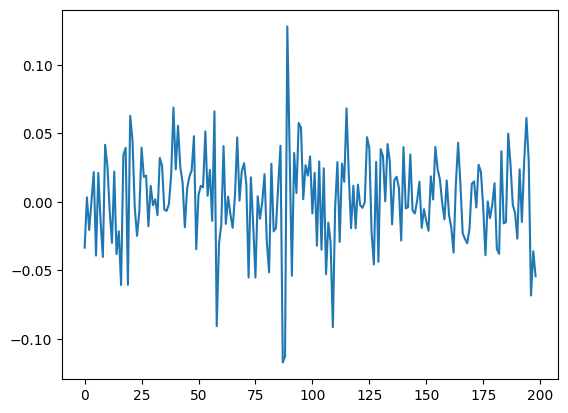

In [20]:
data_for_ml_train['delta_target'].plot()

In [21]:
print(adfuller(data_for_ml_train['delta_target']))

(np.float64(-11.120177347408669), np.float64(3.48178873842143e-20), 1, 197, {'1%': np.float64(-3.463987334463603), '5%': np.float64(-2.8763259091636213), '10%': np.float64(-2.5746515171738515)}, np.float64(-715.8329660384416))


#5-year data

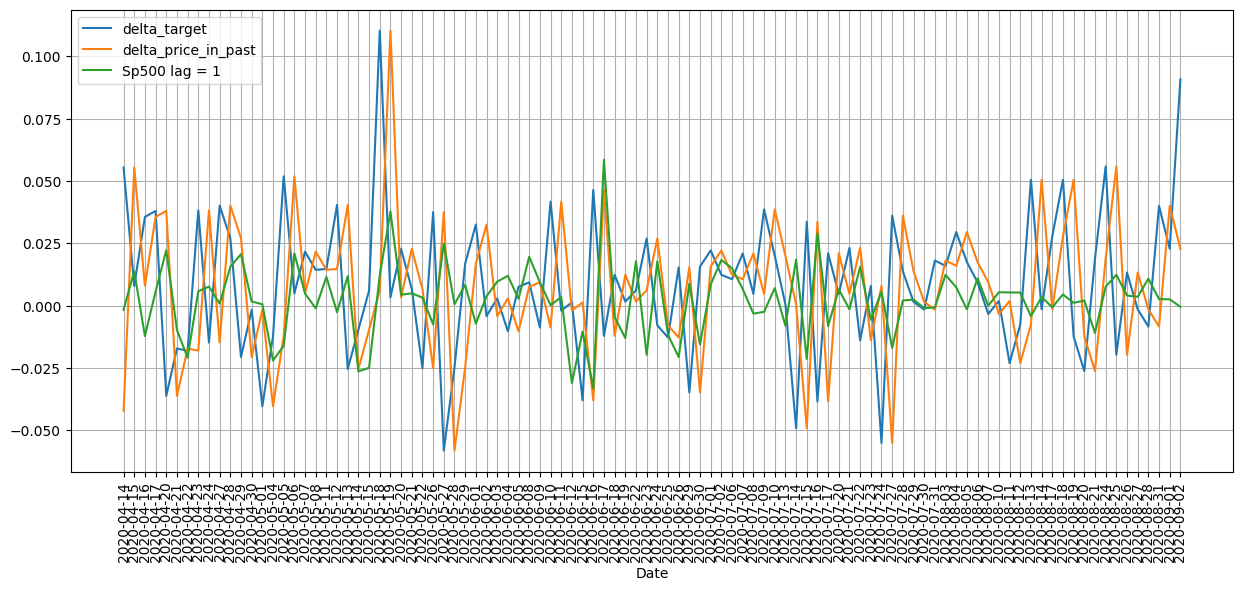

In [22]:
data_for_ml = pd.read_csv('trading_5y.csv', sep = ',')

data_for_ml1 = data_for_ml[0:100]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(data_for_ml1['Date'], data_for_ml1['delta_target'], label='delta_target')
ax.plot(data_for_ml1['Date'], data_for_ml1['delta_price_in_past'], label='delta_price_in_past')
ax.plot(data_for_ml1['Date'], data_for_ml1['delta_sp500_in_past'], label='Sp500 lag = 1')
ax.set_xlabel('Date')
ax.set_xticks(data_for_ml1['Date'])
plt.xticks(rotation=90)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

In [23]:
min_app = 0
data_for_ml.loc[data_for_ml['delta_target'] > min_app, 'class'] = 'yes'
data_for_ml.loc[data_for_ml['delta_target'] <= min_app, 'class'] = 'no'

data_for_ml_train = data_for_ml[:int(len(data_for_ml)*0.8):].copy(deep = True)
data_for_ml_test = data_for_ml[int(len(data_for_ml)*0.8)::].copy(deep = True)

In [24]:
data_for_rf_train = data_for_ml_train[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past', 'class']].copy(deep = True)
data_for_rf_test = data_for_ml_test[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past', 'class']].copy(deep = True)
x_train = data_for_rf_train[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past']]
x_test = data_for_rf_test[['Volume_in_past1', 'Volume_in_past2', 'price_in_past1', 'price_in_past2', 'delta_price_in_past', 'delta_volume_in_past', 'sp500', 'sp500_in_past1', 'sp500_in_past2', 'delta_sp500_in_past']]
y_train_rf = data_for_rf_train['class']
y_test_rf = data_for_rf_test['class']

y_train_rf_regr = data_for_ml_train['target']
y_test_rf_regr = data_for_ml_test['target']

y_train_rf_regr1 = data_for_ml_train['delta_target']
y_test_rf_regr1 = data_for_ml_test['delta_target']

y_train_svr1 = data_for_ml_train['target']
y_test_svr1 = data_for_ml_test['target']

y_train_svr2 = data_for_ml_train['delta_target']
y_test_svr2 = data_for_ml_test['delta_target']

In [25]:
data_for_ml_train['target']

,target
0,6.849764
1,6.904561
2,7.150655
3,7.422653
4,7.154641
...,...
998,88.418939
999,88.454938
1000,90.376298
1001,86.837457


<Axes: >

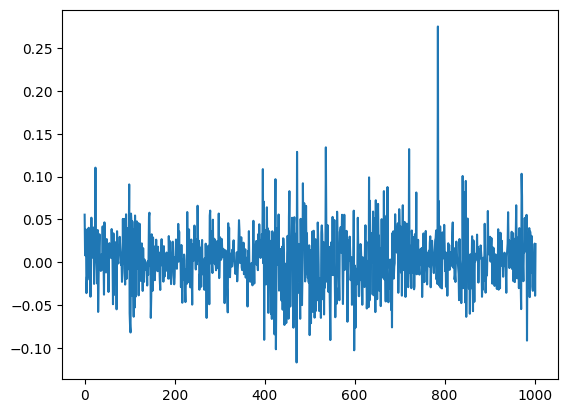

In [26]:
data_for_ml_train['delta_target'].plot()

In [27]:
#random forest classifier
rf_5y = RandomForestClassifier(n_estimators=100, random_state=42)
rf_5y.fit(x_train, y_train_rf)
y_pred_5y = rf_5y.predict(x_test)
accuracy_5y = accuracy_score(y_test_rf, y_pred_5y)
print('random forest classifier')
print(classification_report(y_test_rf, y_pred_5y))

#random forest regression
rf_regr_5y = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regr_5y.fit(x_train, y_train_rf_regr)
y_pred_rf_regr_5y = rf_regr_5y.predict(x_test)
print('random forest regression')
print(mean_squared_error(y_test_rf_regr, y_pred_rf_regr_5y))

#SVM (SVR) regression
svr1_5y = SVR()
svr1_5y.fit(x_train, y_train_svr1)
y_pred_svr1_5y = svr1_5y.predict(x_test)
print('SVM (SVR) regression')
print(mean_squared_error(y_test_svr1, y_pred_svr1_5y))

#radfom forest growth analysis
rf_regr1_5y = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regr1_5y.fit(x_train, y_train_rf_regr1)
y_pred_rf_regr1_5y = rf_regr1_5y.predict(x_test)
print('radfom forest growth analysis')
print(mean_squared_error(y_test_rf_regr1, y_pred_rf_regr1_5y))

#SVM (SVR) growth analysis
svr2_5y = SVR()
svr2_5y.fit(x_train, y_train_svr2)
y_pred_svr2_5y = svr2_5y.predict(x_test)
print('SVM (SVR) growth analysis')
print(mean_squared_error(y_test_svr2, y_pred_svr2_5y))

random forest classifier
              precision    recall  f1-score   support

          no       0.51      0.81      0.63       116
         yes       0.67      0.33      0.45       135

    accuracy                           0.55       251
   macro avg       0.59      0.57      0.54       251
weighted avg       0.60      0.55      0.53       251

random forest regression
1209.2727613786897
SVM (SVR) regression
10935.68511032291
radfom forest growth analysis
0.0015513729768521927
SVM (SVR) growth analysis
0.0019187440457557649


In [28]:
y = data_for_ml_train['delta_target']
x = data_for_ml_train[['delta_price_in_past', 'delta_volume_in_past', 'delta_sp500_in_past']]
model_delta = sm.OLS(y, x)
results = model_delta.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:           delta_target   R-squared (uncentered):                   0.013
Model:                            OLS   Adj. R-squared (uncentered):              0.010
Method:                 Least Squares   F-statistic:                              4.238
Date:                Tue, 20 Jan 2026   Prob (F-statistic):                     0.00548
Time:                        11:10:19   Log-Likelihood:                          1994.8
No. Observations:                1003   AIC:                                     -3984.
Df Residuals:                    1000   BIC:                                     -3969.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [29]:
y = data_for_ml_train['target']
x = data_for_ml_train[['price_in_past1', 'sp500_in_past1', 'delta_volume_in_past']]
model_final = sm.OLS(y, x)
res2 = model_final.fit()
print(res2.summary())

                                 OLS Regression Results                                
Dep. Variable:                 target   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          3.081e+05
Date:                Tue, 20 Jan 2026   Prob (F-statistic):                        0.00
Time:                        11:10:20   Log-Likelihood:                         -1440.7
No. Observations:                1003   AIC:                                      2887.
Df Residuals:                    1000   BIC:                                      2902.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [30]:
# Error: sum((target - predict)^2)
err = pd.DataFrame()
err['rf'] = (y_pred_rf_regr_5y - data_for_ml_test['target']) ** 2
err['svr'] = (y_pred_svr1_5y - data_for_ml_test['target']) ** 2
err.sum()

,0
rf,3.035275e+05
svr,2.744857e+06


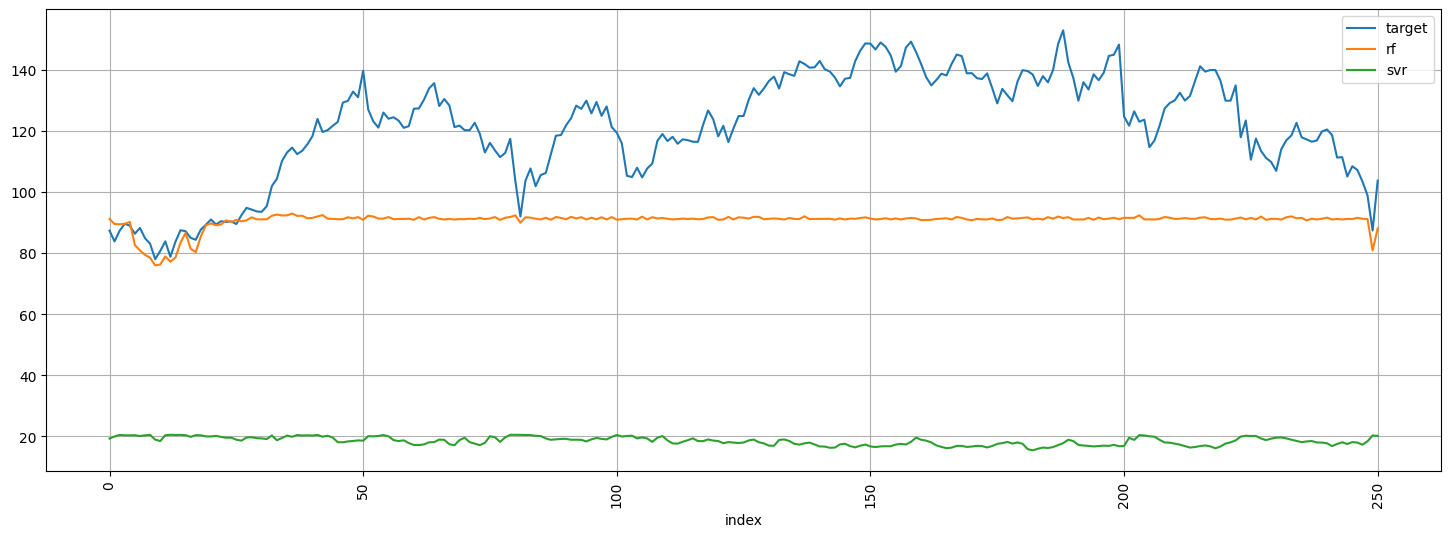

In [31]:
mas_of_x = np.arange(0, len(data_for_ml_test['target']))

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(mas_of_x, data_for_ml_test['target'], label='target')
ax.plot(mas_of_x, y_pred_rf_regr_5y, label='rf')
ax.plot(mas_of_x, y_pred_svr1_5y, label='svr')

ax.set_xlabel('index')
plt.xticks(rotation = 90)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

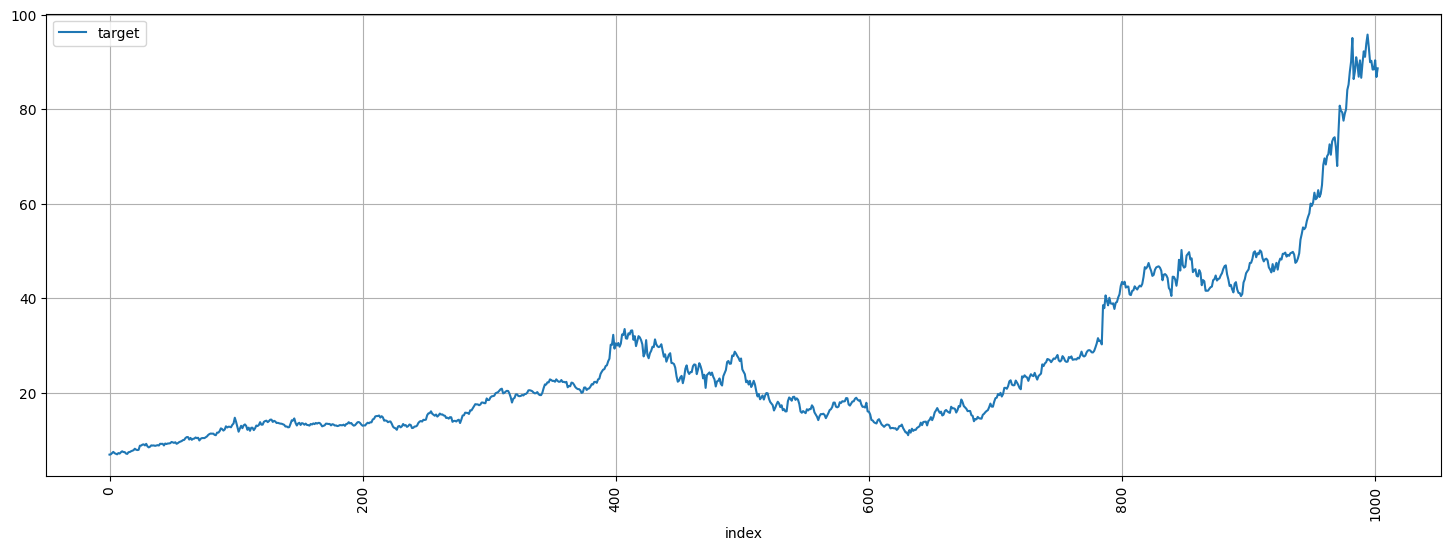

In [32]:
mas_of_x = np.arange(0, len(data_for_ml_train['target']))

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(mas_of_x, data_for_ml_train['target'], label='target')

ax.set_xlabel('index')
plt.xticks(rotation = 90)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

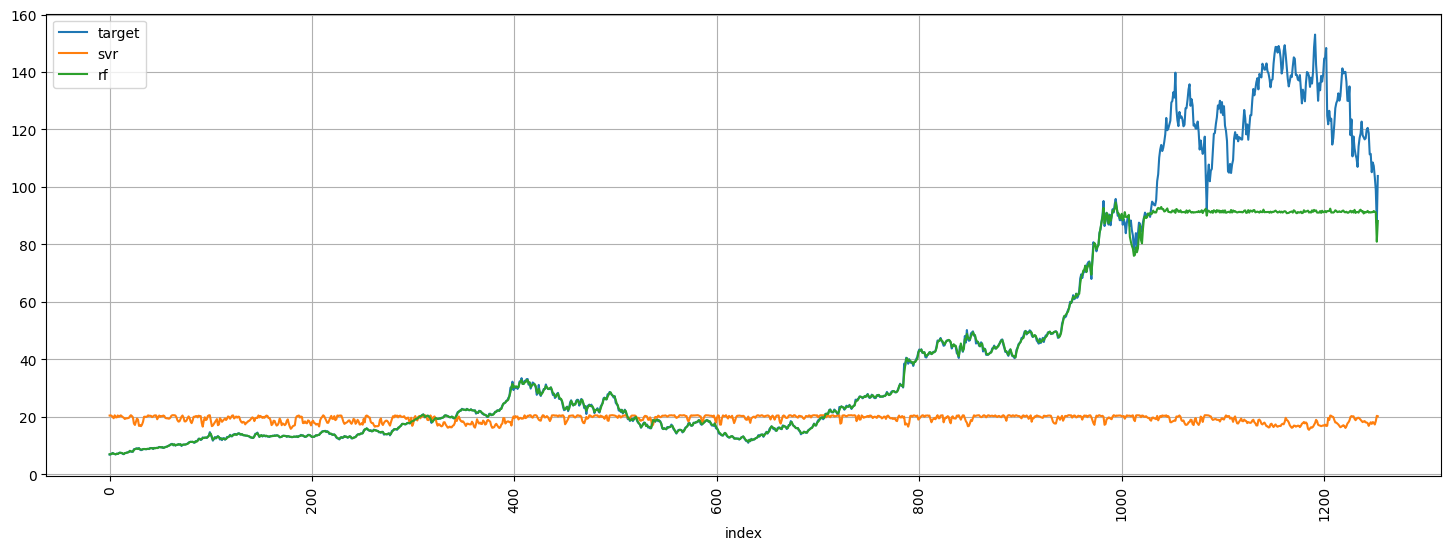

In [33]:
y_pr_train_svr = svr1_5y.predict(x_train)
y_pr_test_svr = svr1_5y.predict(x_test)

svr_array = np.append(y_pr_train_svr, y_pr_test_svr)

y_pr_train_rf = rf_regr_5y.predict(x_train)
y_pr_test_rf = rf_regr_5y.predict(x_test)

rf_array = np.append(y_pr_train_rf, y_pr_test_rf)

mas_of_x = np.arange(0, len(data_for_ml['target']))

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(mas_of_x, data_for_ml['target'], label='target')
ax.plot(mas_of_x, svr_array, label='svr')
ax.plot(mas_of_x, rf_array, label='rf')

ax.set_xlabel('index')
plt.xticks(rotation = 90)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

In [34]:
#errors in ml increments methods
err_prir = pd.DataFrame()
err_prir['rf'] = (y_pred_rf_regr1_5y - data_for_ml_test['delta_target']) ** 2
err_prir['svr'] = (y_pred_svr2_5y - data_for_ml_test['delta_target']) ** 2
err_prir.sum()

,0
rf,0.389395
svr,0.481605


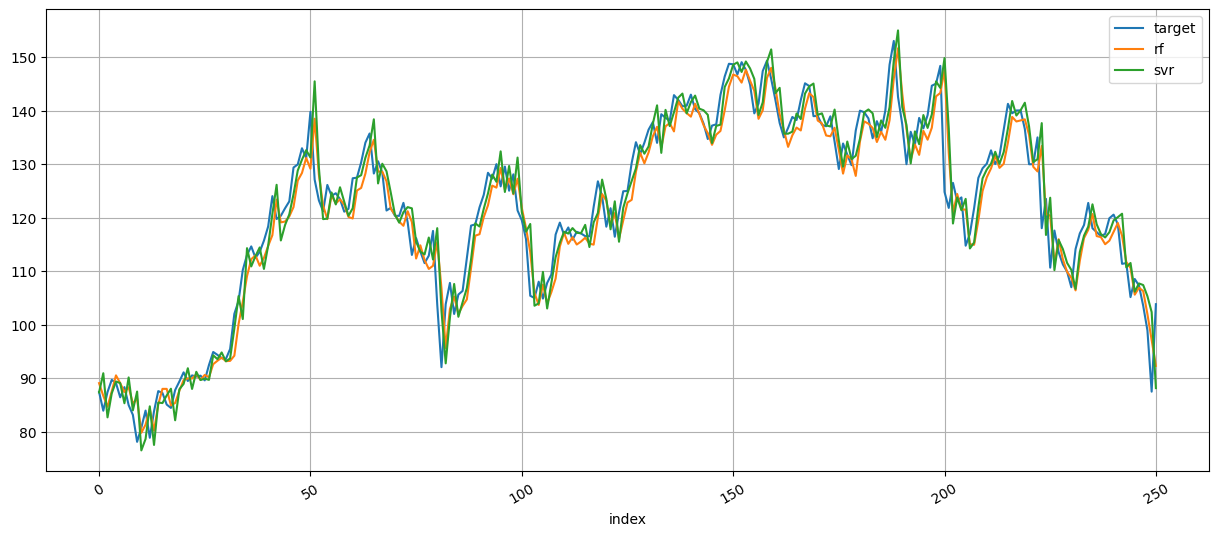

In [35]:
#graphs derived from increments
fig, ax = plt.subplots(figsize=(15, 6))
mas_of_x = np.arange(0, len(data_for_ml_test['target']))



prediction_rf = (y_pred_rf_regr1_5y + 1) * data_for_ml_test['price_in_past1']
prediction_svr = (y_pred_svr2_5y + 1) * data_for_ml_test['price_in_past1']

ax.plot(mas_of_x, data_for_ml_test['target'], label='target')
ax.plot(mas_of_x, prediction_rf, label='rf')
ax.plot(mas_of_x, prediction_svr, label='svr')

ax.set_xlabel('index')
plt.xticks(rotation = 30)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()

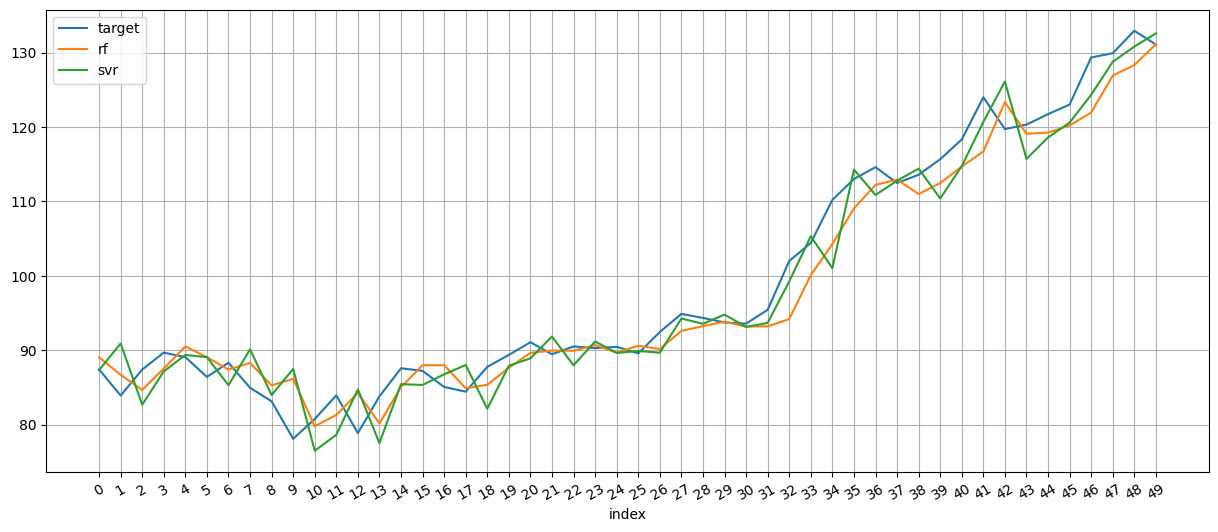

In [36]:
#graphs derived from increments
fig, ax = plt.subplots(figsize=(15, 6))
mas_of_x = np.arange(0, len(data_for_ml_test['target'][0:50:]))



prediction_rf = (y_pred_rf_regr1_5y + 1) * data_for_ml_test['price_in_past1']
prediction_svr = (y_pred_svr2_5y + 1) * data_for_ml_test['price_in_past1']

ax.plot(mas_of_x, data_for_ml_test['target'][0:50:], label='target')
ax.plot(mas_of_x, prediction_rf[0:50:], label='rf')
ax.plot(mas_of_x, prediction_svr[0:50:], label='svr')

ax.set_xlabel('index')
ax.set_xticks(mas_of_x)
plt.xticks(rotation = 30)
ax.set_ylabel('')
ax.legend()
plt.grid()
plt.show()